# Exploración de optimizaciones de GTFS

El presente notebook explora posibles optimizaciones para archivos GTFS, en el
contexto de disminuir el tiempo de computación de TTMs. Se comparan los tiempos
de computación de las TTMs tras las optimizaciones, junto con los resultados
obtenidos en cada caso.

Se utilizará la comuna de Providencia para obtener los orígenes. Los destinos
serán hospitales y clínicas dentro de la envoltura convexa de todo el Gran
Santiago; al tener un alcance mayor a una farmacia o un supermercado, es de
esperar que las personas utilicen transporte público para llegar a su hospital
o clínica más cercana.

Se compararán los siguientes tipos de preprocesamiento:

- **GTFS estándar**: el mismo que se descargó originalmente. Este va a entregar
  los tiempos más precisos, por lo cual lo usaremos como la ``verdad''.
- **Convert frequencies**: "expandir" el archivo `frequencies.txt` a una
  versión equivalente en `stop_times.txt` y `trips.txt`. Para esto se utiliza
  el método `clean_gtfs_frequencies`.
- **Cluster stops**: reducir la cantidad de paraderos que debe visitar el
  algoritmo, haciendo *clustering* de aquellos que se encuentren cercanos. Se
  utilizará DBSCAN con `eps=100` y `min_samples=1`.
- **Convert + cluster**: aplica las dos modificaciones mencionadas
  anteriormente al mismo tiempo.

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import partridge as ptg
from sklearn.cluster import DBSCAN
from copy import copy

from r5py.util.config import Config

import datetime
from time import time
from pathlib import Path

In [4]:
import xmin
from xmin.dataset import (
    extract_osm_subset,
    clean_gtfs_basic,
    clean_gtfs_frequencies,
)
from xmin.dataset.gtfs import seconds_to_gtfs_time

In [5]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
IMG_PATH = Path("../../reports/figures")

In [6]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_SALUD_PATH = PRE_DATA_PATH / "amenities" / "salud.gpkg"
OSM_SANTIAGO_PATH = PRE_DATA_PATH / "osm" / "Santiago.osm.pbf"

## Orígenes y destinos

In [7]:
# carga de datos y cambio de sistema de coordenadas
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24"
)
limites_urbanos = limites_urbanos_full.to_crs(4326)

# filtramos solo las áreas de interés
limites_urbanos = limites_urbanos[
    (limites_urbanos["LOCALIDAD"] == "GRAN SANTIAGO")
]

# obtenemos envoltura convexa para extraer POIs y red vial
limites_envoltura = limites_urbanos.union_all().convex_hull

# solo usaremos orígenes en Providencia
providencia = limites_urbanos[limites_urbanos["COMUNA"]=="PROVIDENCIA"]

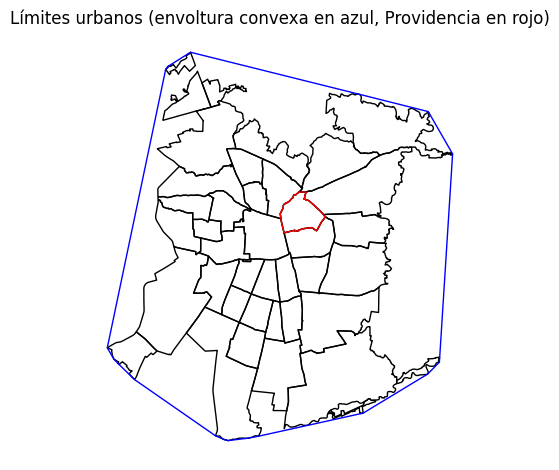

In [8]:
ax = limites_urbanos.plot(facecolor="none", edgecolor="black")
gpd.GeoSeries([limites_envoltura]).plot(
    ax=ax, facecolor="none", edgecolor="blue"
)
providencia.plot(ax=ax, facecolor="none", edgecolor="red")
ax.set_axis_off()
plt.title("Límites urbanos (envoltura convexa en azul, Providencia en rojo)")
plt.tight_layout()

In [9]:
origins = xmin.Origins.create_grid(
    regions=providencia,
    h3_resolution=9,
)
len(origins.h3_grid)

158

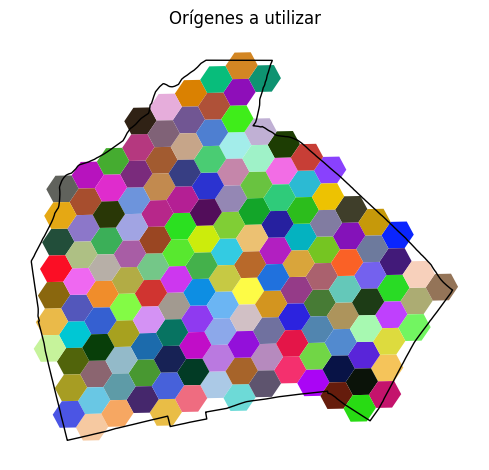

In [10]:
ax = origins.h3_grid.plot(color=np.random.random((len(origins.h3_grid), 3)))
providencia.plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
plt.title("Orígenes a utilizar")
plt.tight_layout()

In [11]:
if not OSM_SANTIAGO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_SANTIAGO_PATH,
        bounds=limites_envoltura
    )

In [12]:
salud_gdf = gpd.read_file(AMENITY_SALUD_PATH)

salud = xmin.Amenity(
    name="salud",
    amenity_gdf=salud_gdf[salud_gdf["TIPO"].isin(["Hospital", "Clínica"])],
    bounds=limites_envoltura
)

## Preprocesamiento

In [13]:
GTFS_RAW_PATH = RAW_DATA_PATH / "gtfs" / "Santiago.zip"

GTFS_NORMAL_PATH = PRE_DATA_PATH / "gtfs" / "Santiago_Normal.zip"
GTFS_CONVERT_FREQ_PATH = PRE_DATA_PATH / "gtfs" / "Santiago.zip"
GTFS_CLUSTER_STOP_PATH = PRE_DATA_PATH / "gtfs" / "Santiago_Cluster.zip"
GTFS_CONVERT_CLUSTER_PATH = (
    PRE_DATA_PATH / "gtfs" / "Santiago_Convert_Cluster.zip"
)

### Normal

In [14]:
clean_gtfs_basic(
    GTFS_RAW_PATH,
    GTFS_NORMAL_PATH
)

### Convert frequencies

In [15]:
clean_gtfs_frequencies(
    GTFS_RAW_PATH,
    GTFS_CONVERT_FREQ_PATH
)

(1/4) Obteniendo ruta de cada viaje...
(2/4) Duplicando viajes según frecuencia...
(3/4) Agregando viajes nuevos a GTFS...
(4/4) Escribiendo archivos...


### Cluster stops

Este método no está implementado en la librería (spoiler: no sirve de mucho),
así que se implementa aquí manualmente.

In [ ]:
feed = ptg.load_feed(GTFS_NORMAL_PATH)
stops_df = feed.stops

In [ ]:
# convert lat/lon to radians for haversine distance
coords = np.radians(stops_df[["stop_lat", "stop_lon"]].values)
kms_per_radian = 6371.0088
eps = 0.1 / kms_per_radian  # 100 m

db = DBSCAN(
    eps=eps, min_samples=1, algorithm="ball_tree", metric="haversine"
).fit(coords)
stops_df["cluster_id"] = db.labels_

In [ ]:
cluster_map = dict(zip(stops_df["stop_id"], stops_df["cluster_id"]))

In [ ]:
def get_representative_point(stops: gpd.GeoDataFrame):
    stops_repr_point = stops.geometry.union_all().representative_point()
    return pd.Series({"geometry": stops_repr_point})

In [ ]:
stops_gdf = gpd.GeoDataFrame(
    stops_df,
    geometry=gpd.points_from_xy(
        stops_df["stop_lon"], stops_df["stop_lat"], crs=4326
    ),
)

clusters_gdf = (
    stops_gdf.groupby("cluster_id")[["geometry"]]
    .apply(get_representative_point)
    .set_crs(4326)
)

In [ ]:
# nuevos paraderos
clusters_df = pd.DataFrame({
    "stop_id": clusters_gdf.index,
    "stop_code": pd.NA,
    "stop_name": clusters_gdf.index,
    "stop_lat": clusters_gdf.geometry.y,
    "stop_lon": clusters_gdf.geometry.x
}).reset_index(drop=True)

In [ ]:
# asignar nuevo paradero a cada detención en stop_times
stop_times_df = copy(feed.stop_times).drop(
    columns=["pickup_type", "drop_off_type", "timepoint"]
)
stop_times_df["stop_id"] = stop_times_df["stop_id"].map(cluster_map)
stop_times_df[["arrival_time", "departure_time"]] = stop_times_df[
    ["arrival_time", "departure_time"]
].map(seconds_to_gtfs_time)

In [ ]:
new_feed = ptg.load_raw_feed(GTFS_NORMAL_PATH)
new_feed.set("stop_times.txt", stop_times_df)
new_feed.set("stops.txt", clusters_df)

In [ ]:
ptg.writers.write_feed_dangerously(new_feed, str(GTFS_CLUSTER_STOP_PATH))

'/home/clau/x-minute-chile/data/processed/gtfs/Santiago_Cluster.zip'

### Convert + cluster

In [16]:
clean_gtfs_frequencies(
    GTFS_CLUSTER_STOP_PATH,
    GTFS_CONVERT_CLUSTER_PATH
)

(1/4) Obteniendo ruta de cada viaje...
(2/4) Duplicando viajes según frecuencia...
(3/4) Agregando viajes nuevos a GTFS...
(4/4) Escribiendo archivos...


## Cálculo de TTMs

Para cada método de preprocesamiento, calcularemos su TTM correspondiente.

**Nota**: se realizó una ejecución previa de todas las computaciones, para que
las `TransportNetwork` de r5py sean guardadas en caché; de esta manera, solo se
comparan los tiempos de cálculo "real" y no la construcción de la red de
transporte (que se realiza una vez y se puede reutilizar).

In [25]:
gtfs_paths = {
    "normal": GTFS_NORMAL_PATH,
    "convert": GTFS_CONVERT_FREQ_PATH,
    "cluster": GTFS_CLUSTER_STOP_PATH,
    "convert_cluster": GTFS_CONVERT_CLUSTER_PATH
}
times = {}
ttms_per_gtfs = {}

for gtfs_name, gtfs_path in gtfs_paths.items():
    print(f"GTFS: {gtfs_name}")
    for f in Config().CACHE_DIR.glob("*.mapdb"):
        f.unlink()  # remove cached files
    t0 = time()
    ttms = xmin.TravelTimeMatrices.compute(
        origins=origins,
        amenities=[salud],
        gtfs_paths=gtfs_path,
        osm_path=OSM_SANTIAGO_PATH,
        snap_to_network=True,
        max_time=datetime.timedelta(minutes=60),
        transport_modes=["WALK", "TRANSIT"],
        chunk_size=10
    )
    t1 = time()
    times[gtfs_name] = t1 - t0
    ttms_per_gtfs[gtfs_name] = ttms

GTFS: normal
Calculando tiempos de viaje desde cada origen...


  0%|          | 0/158 [00:00<?, ?it/s]

GTFS: convert
Calculando tiempos de viaje desde cada origen...


  0%|          | 0/158 [00:00<?, ?it/s]

GTFS: cluster
Calculando tiempos de viaje desde cada origen...


  0%|          | 0/158 [00:00<?, ?it/s]

GTFS: convert_cluster
Calculando tiempos de viaje desde cada origen...


  0%|          | 0/158 [00:00<?, ?it/s]

## Comparaciones

Notamos que los tiempos de cálculo con los GTFS que incluyen "Convert
frequencies" son un orden de magnitud más rápidos que los mismos cálculos con
los GTFS que mantienen `frequencies.txt`. No existe una mejora notoria con la
optimización "Cluster stops".

In [26]:
times

{'normal': 228.61979985237122,
 'convert': 23.47245955467224,
 'cluster': 232.72381234169006,
 'convert_cluster': 24.702808380126953}

In [28]:
ttm_comparison = pd.concat([
    ttms.matrices[salud].set_index(["from_id", "to_id"]).squeeze().rename(name)
    for name, ttms in ttms_per_gtfs.items()
], axis=1).rename(columns={
    "normal": "Normal",
    "convert": "Convert frequencies",
    "cluster": "Cluster stops",
    "convert_cluster": "Convert + cluster"
})

In [29]:
ttm_comparison

Normal  Convert frequencies  Cluster stops  \
from_id         to_id                                                    
89b2c55682bffff salud/2366     NaN                  NaN            NaN   
                salud/2384     NaN                  NaN           59.0   
                salud/2413     NaN                  NaN            NaN   
                salud/2420    58.0                 57.0           54.0   
                salud/2438     NaN                  NaN            NaN   
...                            ...                  ...            ...   
89b2c50b61bffff salud/4329    57.0                 58.0           51.0   
                salud/4398    28.0                 27.0           29.0   
                salud/4403    19.0                 19.0           17.0   
                salud/4430    52.0                 51.0           45.0   
                salud/4635    48.0                 49.0           45.0   

                            Convert + cluster  
from_id         to_id                          
89b2c55682bffff salud/2366               59.0  
                salud/2384               59.0  
                salud/2413                NaN  
                salud/2420               52.0  
                salud/2438                NaN  
...                                       ...  
89b2c50b61bffff salud/4329               49.0  
                salud/4398               27.0  
                salud/4403               17.0  
                salud/4430               47.0  
                salud/4635               45.0  

[18644 rows x 4 columns]

In [34]:
ttm_diff = ttm_comparison.drop(columns="Normal").sub(
    ttm_comparison["Normal"], axis=0
)

ttm_diff.describe()

,Convert frequencies,Cluster stops,Convert + cluster
count,15456.000000,15520.000000,15521.000000
mean,-0.168931,-2.592848,-2.718897
std,1.170873,2.170309,2.345930
min,-10.000000,-12.000000,-12.000000
25%,-1.000000,-4.000000,-4.000000
50%,0.000000,-2.000000,-3.000000
75%,0.000000,-1.000000,-1.000000
max,7.000000,5.000000,5.000000


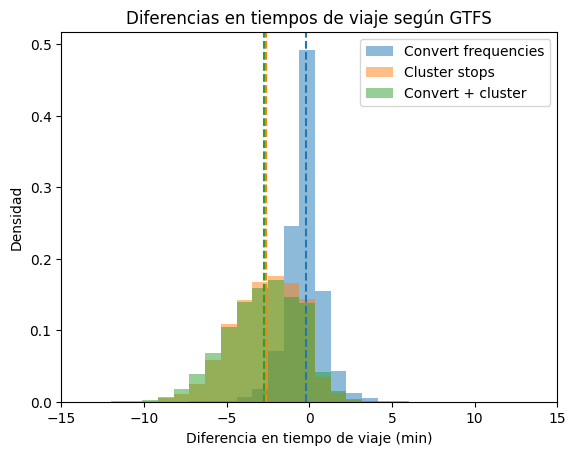

In [ ]:
ax = ttm_diff.plot.hist(
    legend=True, xlim=[-15, 15], alpha=0.5, bins=20, density=True
)
ax.set_xlabel("Diferencia en tiempo de viaje (min)")
ax.set_ylabel("Densidad")
ax.axvline(ttm_diff["Convert frequencies"].mean(), color="tab:blue", ls="--")
ax.axvline(ttm_diff["Cluster stops"].mean(), color="tab:orange", ls="--")
ax.axvline(ttm_diff["Convert + cluster"].mean(), color="tab:green", ls="--")
plt.title("Diferencias en tiempos de viaje según GTFS")
plt.legend()
plt.savefig(IMG_PATH / "gtfs_ttm_comparison.pdf")

Comparando los tiempos de viaje obtenidos con las distintas optimizaciones de
GTFS (en relación a los tiempos de viaje obtenidos con el GTFS original), se
observa que los tiempos con "Convert frequencies" son muy similares a los
tiempos obtenidos con el GTFS original. Casi todos los viajes sufren
diferencias de no más de 5 minutos, con casi un 50% manteniéndose sin
diferencias.

Por el contrario, "Cluster stops" y "Convert + cluster" consistentemente
subestiman los tiempos de viaje (~2.5 minutos en promedio). Esto se debe a que
los métodos no consideran tiempos de combinación en sus cálculos (paraderos
cercanos se consideran como uno solo).

Por ende, se utilizará solamente "Convert frequencies" para la optimización de
archivos GTFS.